In [2]:
import numpy as np
import matplotlib.pyplot as plt

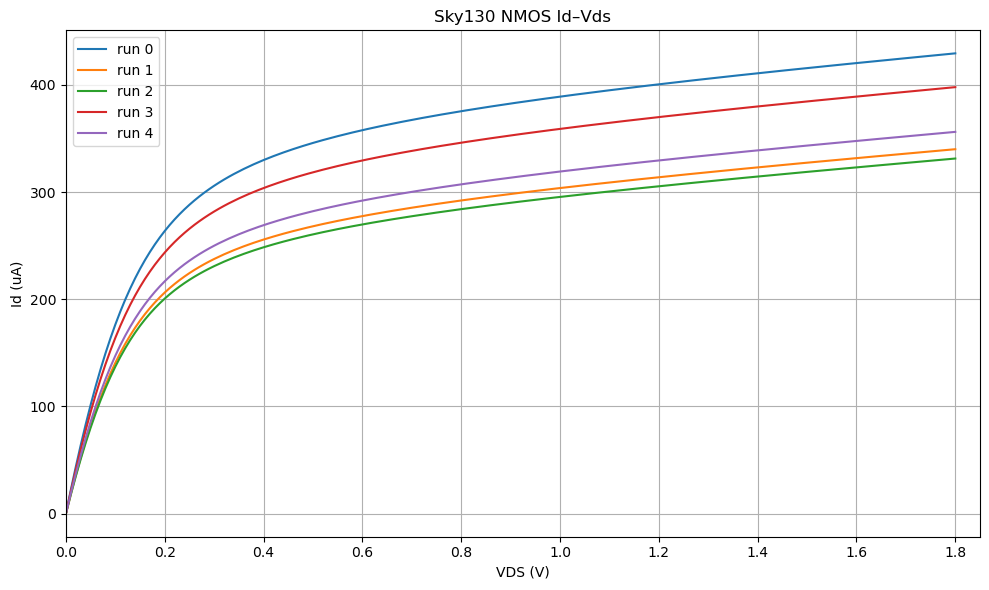

In [16]:
# VGS sweep for variable VDS
'''steps = ['0', '1', '2', '3', '4', '5']
plt.figure(figsize=(10,6))


for item in steps:

    data1 = np.loadtxt(f"vgs_sweep_step{item}.txt")
    
    # columns: [Vgate, I(VDD)]
    vg1 = data1[:,0]
    idrain1 = data1[:,3]   # sign correction
    vd1 = data1[0,5]
    #plt.figure(figsize=(10,6))
    plt.plot(vg1, idrain1 * 1e6, label= f'VDS = {vd1}')
plt.xlim(0, 1.85)                              # Forces the view limit up to 1.85
plt.xticks(np.arange(0, 1.9, 0.2))

plt.title("Sky130 NMOS Id–Vgs")
plt.xlabel("VGS (V)")
plt.ylabel("Id (uA)")
plt.legend()
plt.grid(True)
    
plt.tight_layout()
plt.show()'''

#VDS sweep variable VGS
dSteps = ['0', '1', '2', '3', '4']
plt.figure(figsize=(10,6))


for step in dSteps:
    DS = np.loadtxt(f"{step}_mosfetVDS_MC_all.csv", delimiter=",", skiprows=1)

    
    
    vd3 = DS[:,0]
    id3 = -DS[:,3]   
    #vg3 = DS[0,1]
    
    
    plt.plot(vd3, id3 * 1e6, label = f'run {step}' )
plt.xlim(0, 1.85)                              # Forces the view limit up to 1.85
plt.xticks(np.arange(0, 1.9, 0.2))
plt.title("Sky130 NMOS Id–Vds")
plt.xlabel("VDS (V)")
plt.ylabel("Id (uA)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
import csv
import sys
inde = [0, 1, 2, 3, 4]

for i in inde:
# Define your file paths
    input_file = f"{i}_mosfetvds_mc_all.dat"
    output_file = f"{i}_mosfetVDS_MC_all.csv"
    
    # Your exact custom headers (including the initial sweep scale column)
    headers = ["vSweep", "run_num", "vd", "id", "vth0", "u0", "rdsw", "nfactor", "vsat", "eta0"]
    
    with open(input_file, 'r') as infile, open(output_file, 'w', newline='') as outfile:
        writer = csv.writer(outfile)
        
        # 1. Write the clean header first
        writer.writerow(headers)
        
        # 2. Skip NGSPICE's internal header line, then process the rows
        next(infile) 
        for line in infile:
            # Split the line by any whitespace and filter out empty strings
            row = [val for val in line.strip().split() if val]
            if row:
                writer.writerow(row)